# Bluesky Data Science
## Part 05 - Time Series and Causal Inference: Event Studies on Bluesky

June 2026
Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

## Background

> **tl;dr**: We collect the complete posting histories of two Bluesky accounts, turn them into time series, explore their daily and weekly rhythms, and then use two quasi-experimental research designs — interrupted time series and difference-in-differences — to ask whether a real event (the post-election Bluesky surge of November 2024) *changed* posting behavior.

Every post, reply, and repost on Bluesky carries a timestamp, which means an account's feed is more than a pile of content: it is a **behavioral trace over time**. Fifteen years of Twitter research showed how much social science lives inside those traces — Golder & Macy (2011) found that mood follows daily and seasonal rhythms across cultures by timestamping millions of tweets, Dodds et al. (2011) built a real-time "hedonometer" of collective happiness, and González-Bailón et al. (2011) reconstructed the minute-by-minute dynamics of protest recruitment during Spain's 15-M movement.

Time series also let us ask a more ambitious kind of question. When something happens in the world — an election, a platform migration, a policy change — we want to know whether behavior changed *because of it*. A line that goes up after an event is not an answer: posting might have been trending upward already, the change might be seasonal, or something else might have happened at the same time. Answering causal questions with observational data requires **research designs**, not just plots. This notebook introduces two workhorse designs from the quasi-experimental toolkit:

* **Interrupted time series (ITS)**: model the pre-event trend, and ask whether the level or slope of the series breaks at the event.
* **Difference-in-differences (DiD)**: compare the before–after change for a "treated" unit against the before–after change for a comparison unit that was *not* affected by the event.

Both designs come from the program-evaluation toolkit that economists and epidemiologists reach for when randomized experiments are impossible. If causal inference is new to you, two free online textbooks pair beautifully with this notebook and we will link to specific chapters as we go: Scott Cunningham's [*Causal Inference: The Mixtape*](https://mixtape.scunning.com/) and Nick Huntington-Klein's [*The Effect: An Introduction to Research Design and Causality*](https://theeffectbook.net/).

We will apply both to a genuine **natural experiment** — an event whose timing was determined by outside forces rather than by the people whose behavior we measure: the surge of new users and activity that hit Bluesky in the days after the U.S. presidential election on November 5, 2024 — and we will be candid about where our designs succeed and where they fail.

### Learning objectives

By the end of this notebook you will be able to:

1. Paginate through an account's **complete posting history** with `get_author_feed` and flatten it into a tidy DataFrame.
2. Parse ISO-8601 timestamps into a **timezone-aware** pandas `DatetimeIndex` and reason about UTC versus local time.
3. **Resample** event-level data to daily and weekly counts, smooth with rolling means, and describe diurnal and weekly rhythms.
4. Specify and interpret an **interrupted time series (segmented) regression** with statsmodels, including its autocorrelation caveats.
5. Build a tidy two-account panel and estimate a **difference-in-differences** regression — and diagnose when the parallel-trends assumption fails.
6. Retrieve **profile covariates** with `get_profiles` to reason about matching a better comparison group.
7. Articulate the **threats to validity** (selection, anticipation, concurrent shocks) that separate causal claims from correlational ones.

## Setup

We need our usual libraries plus [statsmodels](https://www.statsmodels.org/), the standard Python library for regression modeling. Both causal designs in this notebook ultimately boil down to a single call to [ordinary least squares (OLS) regression](https://www.statsmodels.org/stable/regression.html) — the same line-fitting workhorse from introductory statistics — applied to carefully constructed columns. We also import `durbin_watson`, a diagnostic for autocorrelation that we will define and use in Section 5.

On the pandas side, the features we lean on hardest — resampling, rolling windows, and timezone conversion — are all documented in the pandas [time series user guide](https://pandas.pydata.org/docs/user_guide/timeseries.html), which is worth keeping open in a browser tab throughout this part.

In [1]:
# Reading and writing JSON metadata
import json

# Polite pauses between API calls
import time

# DataFrames and numerics
import numpy as np
import pandas as pd

# Data visualization
%matplotlib inline
import matplotlib.pyplot as plt

# Regression modeling for ITS and DiD
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

As in the other parts of this series, `bsky_client.py` gives us a client that authenticates with your `atproto.json` credentials if you have them, and otherwise falls back to the unauthenticated public AppView. Everything in this notebook except the keyword-search section works without logging in.

This part also comes with a helper module, [`timeseries.py`](timeseries.py), that wraps the repetitive pieces — pagination, datetime parsing, resampling, and the regression design matrices — so the notebook can focus on the research design. Open the file and read along: every function is short and documented.

In [2]:
from bsky_client import get_client, is_authenticated

client = get_client()

No atproto.json found: using the unauthenticated public AppView.
Read endpoints work; search and write endpoints require logging in.


Next we import the helper functions from `timeseries.py`. Here is a quick map of what each one does, in the order the notebook uses them:

* `fetch_history` — paginate an account's entire author feed (with the raw-JSON fallback described in Section 1),
* `history_to_frame` — parse the records into a timezone-aware, time-indexed DataFrame (Section 2),
* `daily_counts` / `weekly_counts` — resample the event log onto regular daily and weekly grids (Section 3),
* `fit_its` — build and fit the interrupted time series regression (Section 5),
* `coefficient_table` — tidy a fitted regression into a small, saveable DataFrame,
* `make_did_panel` / `fit_did` — build and fit the difference-in-differences regression (Section 6),
* `get_profile_covariates` — batch-fetch the profile statistics we use for matching (Section 7).

In [3]:
from timeseries import (
    fetch_history,
    history_to_frame,
    daily_counts,
    weekly_counts,
    fit_its,
    coefficient_table,
    make_did_panel,
    fit_did,
    get_profile_covariates,
)

## 1. Collecting complete posting histories

A time series analysis needs the *complete* history of an account, not just its most recent page. `get_author_feed` ([`app.bsky.feed.getAuthorFeed`](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed)) returns at most 100 feed items per request, so — exactly as in Part 01 — we walk the `cursor` parameter until the feed is exhausted, sleeping briefly between requests to be polite.

We will collect two accounts:

* **`brianckeegan.com`** — the author of this series, our "treated" account for the causal designs later, and
* **`bsky.app`** — the official Bluesky account (which posts far less often), which we will (mis)use as a comparison account in Section 6.

Two practical details handled by `fetch_history` in `timeseries.py` are worth reading the source for:

1. **An author feed is more than original posts.** Each feed item can be an original post, a reply, or a repost (flagged by the item's `reason`). We record an `action` type for each, and we timestamp reposts by *when the account reposted* (`reason.indexed_at`), not when the underlying post was created — the act of reposting is the behavior we want to place in time.
2. **Lexicons evolve faster than SDKs.** While building this notebook, one account's feed contained a brand-new embed type (`app.bsky.embed.gallery#view`) that the atproto SDK's validators did not recognize yet, which makes the SDK reject the entire page. `fetch_history` catches that `ModelError` and re-requests the page as raw JSON from the public AppView. Bluesky is a platform in flux; collection code that will run for months needs this kind of defensive fallback.

We also practice **data minimization** (see Part 01): out of everything in each feed item, we keep only the handful of fields this analysis needs — URI, action type, timestamp, and engagement counts.

In [4]:
TREATED = 'brianckeegan.com'
COMPARISON = 'bsky.app'

treated_records = fetch_history(client, TREATED)
comparison_records = fetch_history(client, COMPARISON)

print(f'{TREATED}: {len(treated_records):,} actions')
print(f'{COMPARISON}: {len(comparison_records):,} actions')

brianckeegan.com: 8,190 actions
bsky.app: 903 actions


About three years of activity each. Every record is a small dictionary — here is the treated account's most recent one:

In [5]:
treated_records[0]

{'actor': 'brianckeegan.com',
 'uri': 'at://did:plc:obqunmbc6uydprnnioo42ry2/app.bsky.feed.post/3mnux2yxmak25',
 'action': 'repost',
 'is_reply': False,
 'created_at': '2026-06-10T03:35:08.368Z',
 'like_count': 5313,
 'repost_count': 1562,
 'reply_count': 121}

## 2. Timestamps and timezones

Bluesky timestamps are ISO-8601 strings in **UTC** (the trailing `Z` means "Zulu time", +00:00). UTC is the right storage format — it is unambiguous and sorts correctly — but it is the wrong *analysis* format for questions about human rhythms. A post at `04:30Z` is a half-awake 9:30 PM post in Colorado, not an early bird.

`history_to_frame` parses the strings with [`pd.to_datetime(..., utc=True)`](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) into a timezone-aware `DatetimeIndex` and then converts with [`.tz_convert()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.tz_convert.html) (the pandas [time-zone handling guide](https://pandas.pydata.org/docs/user_guide/timeseries.html#time-zone-handling) covers the full machinery). Since the author lives in Boulder, Colorado, we convert to `America/Denver` — and note that we name the *zone*, not the offset: the zone database knows that Denver is UTC-7 in summer (Mountain Daylight Time) and UTC-6 in winter (Mountain Standard Time), so daylight-saving transitions are handled for us.

In [6]:
treated_posts = history_to_frame(treated_records, tz='America/Denver')
comparison_posts = history_to_frame(comparison_records, tz='America/Denver')

treated_posts.head()

,actor,uri,action,is_reply,like_count,repost_count,reply_count
created_at,,,,,,,
2023-05-25 15:38:41.625000-06:00,brianckeegan.com,at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky...,post,False,6,1,1
2023-05-28 22:42:49.117000-06:00,brianckeegan.com,at://did:plc:cpe7g6pmsh76d324gmgurxca/app.bsky...,repost,False,28,3,2
2023-05-31 19:24:37.005000-06:00,brianckeegan.com,at://did:plc:2zp4ys4ruuuahm5k7xpa4sug/app.bsky...,repost,False,19,9,0
2023-05-31 22:55:22.289000-06:00,brianckeegan.com,at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky...,post,False,1,0,1
2023-06-04 15:43:34.042000-06:00,brianckeegan.com,at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky...,post,False,1,0,0


The index is timezone-aware — note the `-06:00`/`-07:00` offsets — and we can move the same instants between zones losslessly. While we are inspecting the frame, `value_counts` on the `action` column shows how the activity breaks down by type:

In [7]:
first_action = treated_posts.index[0]
print('Local (America/Denver):', first_action)
print('UTC:                   ', first_action.tz_convert('UTC'))
print()
print(treated_posts['action'].value_counts())
print()
print('Replies among original posts:', treated_posts['is_reply'].sum())

Local (America/Denver): 2023-05-25 15:38:41.625000-06:00
UTC:                    2023-05-25 21:38:41.625000+00:00

action
repost    4822
post      3368
Name: count, dtype: int64

Replies among original posts: 1763


Reposts actually outnumber original posts — a useful reminder that "posting activity" is a bundle of distinct behaviors. For the rest of the notebook we analyze **all actions together** as a single measure of activity; everything below could be re-run on `treated_posts.query("action == 'post'")` to isolate original posting, and checking whether your findings survive that choice is exactly the kind of robustness check reviewers will ask for.

## 3. Descriptive time series: the rhythms of posting

Before any causal modeling, *look at the data*. The raw records are an **event log** — one row per action, at irregular instants. Most time-series tools instead want a **time series** proper: one number per regular interval (per day, per week). The conversion from one to the other is called **resampling**: pandas' [`.resample()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) groups the event log into fixed-width time bins and aggregates within each bin — here by counting rows (see the [resampling section of the pandas time series guide](https://pandas.pydata.org/docs/user_guide/timeseries.html#resampling)). `daily_counts` and `weekly_counts` in `timeseries.py` are one-line wrappers around `.resample('D')` and `.resample('W')`.

### Daily counts and a rolling mean

Daily counts are noisy — a single quiet Tuesday tells you very little. A **rolling mean** (also called a *moving average*) smooths that noise by replacing each day's value with the average over a window of surrounding days; pandas' [`.rolling()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.rolling.html) does the bookkeeping. Below, the faint line is the raw daily data and the dark line is a **4-week (28-day) centered rolling mean** — the trend your eye should follow.

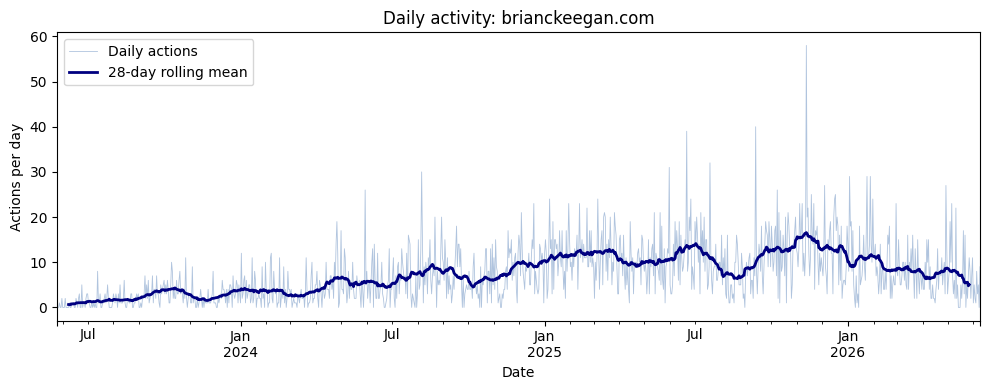

In [8]:
treated_daily = daily_counts(treated_posts, TREATED)

fig, ax = plt.subplots(figsize=(10, 4))
treated_daily.plot(ax=ax, color='lightsteelblue', lw=0.6, label='Daily actions')
treated_daily.rolling(28, center=True).mean().plot(ax=ax, color='navy', lw=2, label='28-day rolling mean')
ax.set_xlabel('Date')
ax.set_ylabel('Actions per day')
ax.set_title(f'Daily activity: {TREATED}')
ax.legend()
plt.tight_layout()

**What to see in this plot.** Activity is low and sporadic early in the series, builds gradually through 2024, explodes in a sharp spike near the end of 2024, and then settles at a level above the old baseline but below the peak. The rolling mean makes that shape legible where the raw daily series is just spiky noise. Keep the shape in mind: the entire causal-inference half of this notebook is an attempt to put numbers — and honest assumptions — around exactly this picture.

### Weekly counts

Resampling to weeks smooths out the day-of-week cycle and gives us the unit of analysis we will use for the causal designs. (`weekly_counts` drops the final, incomplete week so the last observation isn't artificially low just because we collected mid-week.)

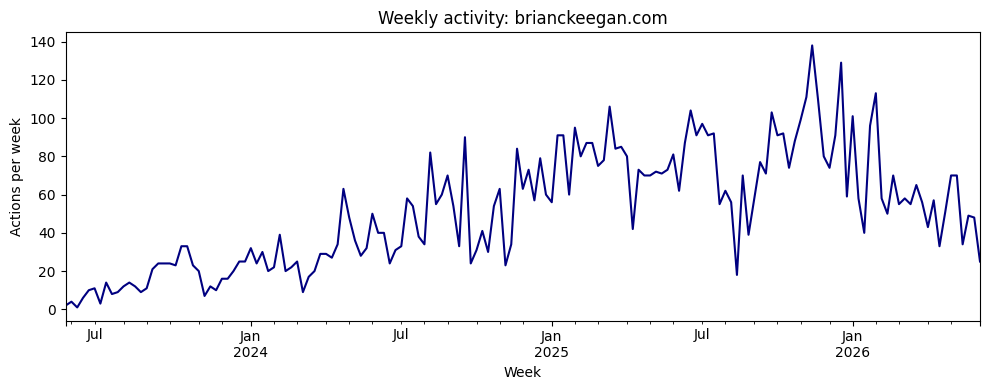

In [9]:
treated_weekly = weekly_counts(treated_posts, TREATED)

fig, ax = plt.subplots(figsize=(10, 4))
treated_weekly.plot(ax=ax, color='navy', lw=1.5)
ax.set_xlabel('Week')
ax.set_ylabel('Actions per week')
ax.set_title(f'Weekly activity: {TREATED}')
plt.tight_layout()

Even at a glance there is a dramatic spike in late 2024 — hold that thought for Section 4.

### Hour-of-day and day-of-week profiles

Golder & Macy (2011) showed that aggregate Twitter activity traces the human day: people wake, work, and wind down on schedule, and their posts follow. We can draw the same **diurnal profile** for one account — and demonstrate why the timezone conversion mattered. The same data binned by UTC hour versus local hour tells two different stories; only the local profile lines up with a plausible human schedule.

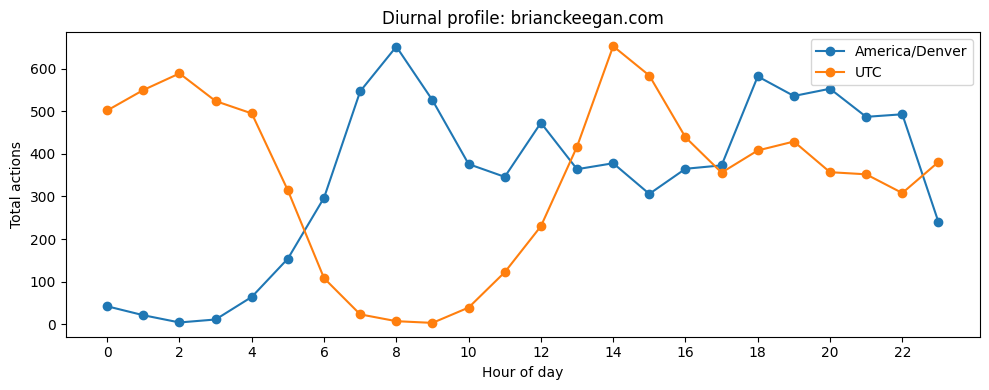

In [10]:
hours = range(24)
hourly_profile = pd.DataFrame({
    'America/Denver': pd.Series(treated_posts.index.hour).value_counts().reindex(hours, fill_value=0),
    'UTC': pd.Series(treated_posts.index.tz_convert('UTC').hour).value_counts().reindex(hours, fill_value=0),
})

fig, ax = plt.subplots(figsize=(10, 4))
hourly_profile.plot(ax=ax, marker='o', lw=1.5)
ax.set_xticks(list(hours)[::2])
ax.set_xlabel('Hour of day')
ax.set_ylabel('Total actions')
ax.set_title(f'Diurnal profile: {TREATED}')
plt.tight_layout()

In local time the account is quiet from roughly midnight to 6 AM — sleep, the most reliable circadian signal in any behavioral trace — with activity through the workday and evening. The UTC curve is the same data shifted by 6–7 hours, which would nonsensically place the quiet hours in the early evening.

The **weekly rhythm** is the second clock human behavior runs on:

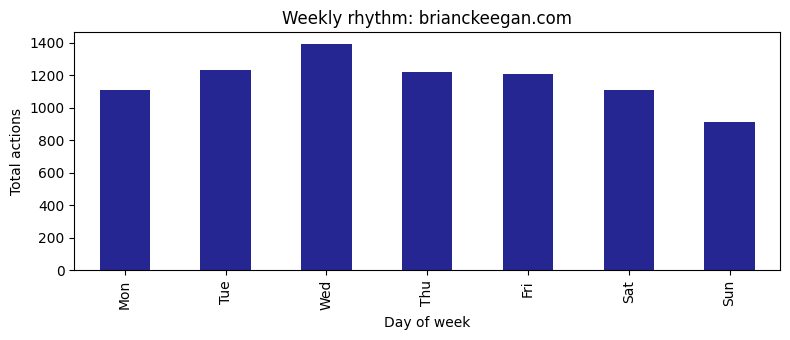

In [11]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_profile = (
    pd.Series(treated_posts.index.dayofweek)
    .value_counts()
    .reindex(range(7), fill_value=0)
)
dow_profile.index = day_names

fig, ax = plt.subplots(figsize=(8, 3.5))
dow_profile.plot.bar(ax=ax, color='navy', alpha=0.85)
ax.set_xlabel('Day of week')
ax.set_ylabel('Total actions')
ax.set_title(f'Weekly rhythm: {TREATED}')
plt.tight_layout()

**Interpretation.** Like nearly every human behavioral trace, the series runs on a weekly clock as well as a daily one — for a person who posts about work, weekdays and weekends are simply different environments. Whatever the exact shape in your run (the notebook re-collects live data), the lesson is that day-of-week variation is *systematic*, not random — which is precisely why the causal models below use **weekly** counts: summing over a full week removes the weekly cycle by construction.

### Year-over-year seasonality

Stacking monthly totals by year shows whether the series has an annual cycle (Golder & Macy found seasonal effects in mood; an academic's posting may track semesters) — and makes long-run shifts in level obvious.

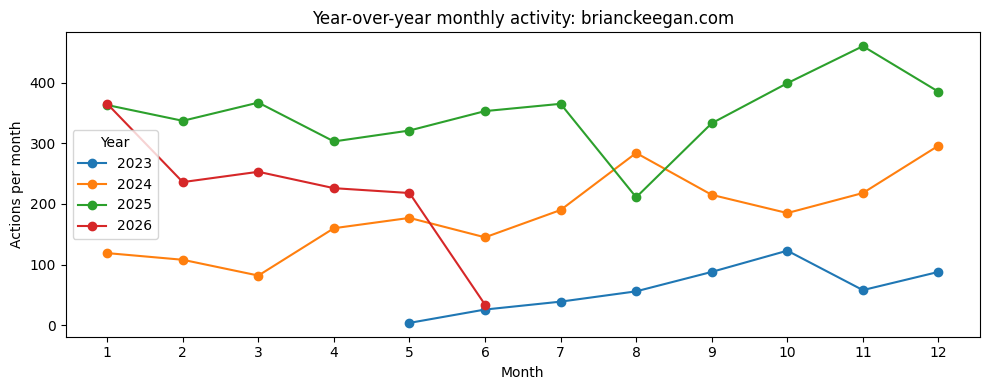

In [12]:
monthly = treated_posts.resample('MS')['uri'].count().to_frame('actions')
monthly['year'] = monthly.index.year
monthly['month'] = monthly.index.month
year_over_year = monthly.pivot_table(index='month', columns='year', values='actions')

fig, ax = plt.subplots(figsize=(10, 4))
year_over_year.plot(ax=ax, marker='o')
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('Actions per month')
ax.set_title(f'Year-over-year monthly activity: {TREATED}')
ax.legend(title='Year')
plt.tight_layout()

With only a few years of data, be cautious about declaring "seasonality": one account's annual pattern is confounded with everything else that happened that year. What *is* unmistakable is that November 2024 towers over every other month. Time to talk about why.

## 4. An event: the November 2024 Bluesky surge

On **November 5, 2024**, Donald Trump won the U.S. presidential election. In the days that followed, large numbers of users — disaffected with X/Twitter and its owner's role in the campaign — migrated to Bluesky. The platform [gained millions of users in roughly a week](https://en.wikipedia.org/wiki/Bluesky#2024:_Growth), media outlets covered the "X-odus", and activity from existing accounts spiked as their timelines filled with new arrivals.

For a researcher this is a **natural experiment**: an event with a sharp, known onset that plausibly changed behavior, but whose timing was not chosen by the people whose behavior we measure. We encode the event date and draw it on the weekly series. The dashed line is the moment everything after which counts as "post-event".

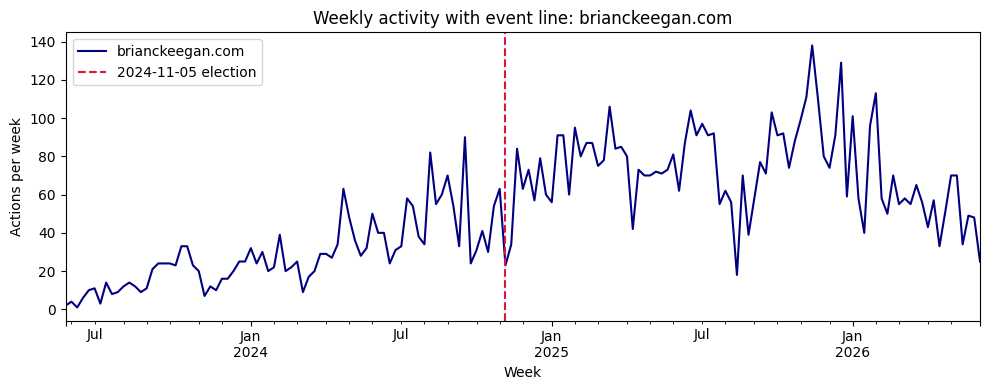

In [13]:
EVENT = pd.Timestamp('2024-11-05', tz='America/Denver')

fig, ax = plt.subplots(figsize=(10, 4))
treated_weekly.plot(ax=ax, color='navy', lw=1.5)
ax.axvline(EVENT, color='crimson', ls='--', lw=1.5, label='2024-11-05 election')
ax.set_xlabel('Week')
ax.set_ylabel('Actions per week')
ax.set_title(f'Weekly activity with event line: {TREATED}')
ax.legend()
plt.tight_layout()

The spike is real and it is right where the story says it should be. But "the line goes up after the event" is journalism, not causal inference. Activity was already drifting upward through 2024 — earlier migration waves, the account's growing network — so *some* increase was coming anyway. The question a causal design answers is: **how much of the change is a break from where the pre-existing trend was already heading?**

## 5. Interrupted time series

The interrupted time series (ITS) design — also called **segmented regression** — formalizes that question. We model weekly counts $y_t$ as a linear trend that is allowed to *break* at the event, in both level and slope:

$$y_t = \beta_0 + \beta_1 t + \beta_2 \, \text{post}_t + \beta_3 \,(t - t_{event})\,\text{post}_t + \varepsilon_t$$

where $t$ counts weeks from the start of the series and $\text{post}_t$ is 1 for weeks on or after the event. Each coefficient has a direct interpretation:

| Term | Meaning |
|---|---|
| $\beta_0$ | baseline level at the start of the series |
| $\beta_1$ | pre-event trend (actions per week, per week) |
| $\beta_2$ | **immediate level shift** at the event |
| $\beta_3$ | **change in slope** after the event |

Three vocabulary words recur in everything you will ever read about this design, so let's define them carefully:

* A **level shift** is an immediate jump (or drop) in the series at the event: the height of the line changes, captured by $\beta_2$.
* A **slope change** (or *trend change*) is a change in the steepness of the series after the event: the line keeps going from wherever it is, but at a new rate, captured by $\beta_3$. An event can produce either, both, or neither.
* The **counterfactual** is the path the series *would have taken* had the event never happened. We can never observe it — that impossibility is sometimes called the *fundamental problem of causal inference* — so every design is, at heart, an argument for a particular stand-in. ITS's stand-in is the pre-event trend $\beta_0 + \beta_1 t$, extended forward as if nothing had happened.

`fit_its` in `timeseries.py` builds this design matrix and fits it with [statsmodels' ordinary least squares, `sm.OLS`](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html). For a friendly, deeper treatment of event-study designs like this one, see [Chapter 17 of *The Effect*](https://theeffectbook.net/ch-EventStudies.html).

In [14]:
its_results, its_design = fit_its(treated_weekly, EVENT)

print(its_results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.620
Method:                 Least Squares   F-statistic:                     87.00
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           4.67e-33
Time:                        11:01:48   Log-Likelihood:                -689.82
No. Observations:                 159   AIC:                             1388.
Df Residuals:                     155   BIC:                             1400.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4422      4.264      1.042      0.2

The `summary()` above is statsmodels' full regression report, and it can be intimidating the first time. The block worth reading is the coefficient table in the middle: `coef` is the estimate itself, `std err` is its uncertainty, `P>|t|` is the p-value for the hypothesis that the true coefficient is zero, and the bracketed pair is the 95% confidence interval (the [statsmodels OLS documentation](https://www.statsmodels.org/stable/regression.html) explains the rest of the report). `coefficient_table` tidies exactly that block into a DataFrame with readable row names (which we will save to `data/` later):

In [15]:
its_table = coefficient_table(
    its_results,
    names=['intercept', 'trend', 'level_shift', 'trend_change'],
)
its_table.round(3)

,coef,std_err,t,p_value
term,,,,
intercept,4.442,4.264,1.042,0.299
trend,0.645,0.098,6.576,0.000
level_shift,24.773,5.966,4.152,0.000
trend_change,-0.790,0.130,-6.054,0.000


**Reading the coefficients** (your numbers will differ slightly because the notebook re-collects live data): in our run the account averaged a handful of actions per week at the start of the series (`intercept`), with activity growing by roughly two-thirds of an action per week each week (`trend`) before the election. At the event the level jumps by about **25 extra actions per week** (`level_shift`) — several times the pre-event weekly average — and the slope then *turns negative* (`trend_change` ≈ −0.8, more than cancelling the +0.65 pre-trend), meaning the surge decays week by week rather than becoming a permanent new baseline. That "spike and partial decay" shape is typical of event-driven attention bursts (González-Bailón et al. 2011 document the same explosive-onset, slow-decay dynamics in protest recruitment).

Plotting observed, fitted, and the **counterfactual** (the pre-trend extended as if the event never happened) makes the design transparent — the causal estimate is the gap between the fitted post-event segment and the dashed counterfactual line:

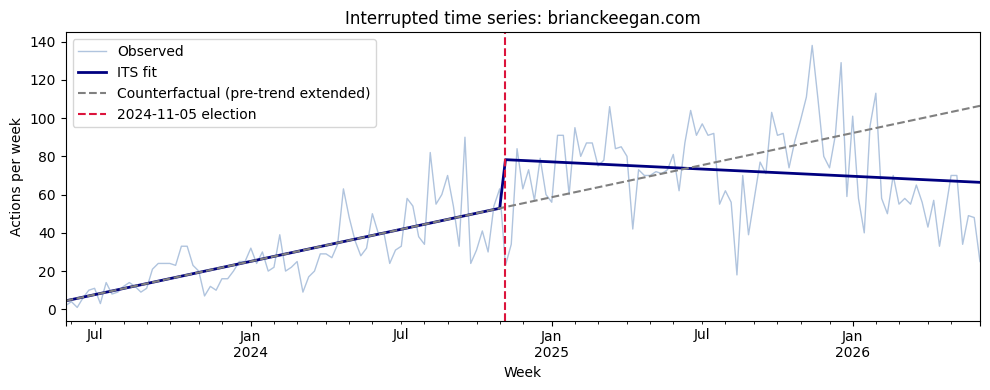

In [16]:
fitted = pd.Series(its_results.fittedvalues, index=treated_weekly.index)
counterfactual = (
    its_results.params['const'] + its_results.params['t'] * its_design['t']
)

fig, ax = plt.subplots(figsize=(10, 4))
treated_weekly.plot(ax=ax, color='lightsteelblue', lw=1, label='Observed')
fitted.plot(ax=ax, color='navy', lw=2, label='ITS fit')
counterfactual.plot(ax=ax, color='gray', ls='--', lw=1.5, label='Counterfactual (pre-trend extended)')
ax.axvline(EVENT, color='crimson', ls='--', lw=1.5, label='2024-11-05 election')
ax.set_xlabel('Week')
ax.set_ylabel('Actions per week')
ax.set_title(f'Interrupted time series: {TREATED}')
ax.legend()
plt.tight_layout()

**How to read this plot.** The gray dashed line is the counterfactual — the pre-event trend extended as if November 5 had never happened. The navy line is the model's fit, which is allowed to break at the event. The vertical gap between the two at the event date is the level shift ($\beta_2$); the way that gap changes over the following months is the slope change ($\beta_3$) at work, here pulling the series back down toward the extrapolated trend. Every ITS estimate you report should be drawn this way: if the picture does not persuade, the coefficient table will not either.

### An honest aside: autocorrelation

OLS standard errors assume the residuals — the model's week-by-week errors — are independent of one another. Time series residuals rarely are: a busy week tends to be followed by a busy week and a quiet one by a quiet one. This serial dependence is called **autocorrelation**, because the series is correlated *with a lagged copy of itself*. The **Durbin–Watson statistic** (also printed in the summary above) diagnoses this: values near 2 indicate no first-order autocorrelation, values well below 2 indicate positive autocorrelation. A value meaningfully below 2 (ours is) means our standard errors are **too small** and our p-values too confident — the coefficients themselves are still unbiased, but we are overstating their precision. The standard first-line fix is to keep the OLS coefficients and replace the standard errors with **Newey–West (HAC)** errors — **H**eteroskedasticity- and **A**utocorrelation-**C**onsistent — which remain valid when residuals are correlated across nearby weeks. statsmodels provides them through [`get_robustcov_results(cov_type='HAC')`](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.get_robustcov_results.html):

In [17]:
print('Durbin-Watson:', round(durbin_watson(its_results.resid), 3))

its_hac = its_results.get_robustcov_results(cov_type='HAC', maxlags=4)

coefficient_table(
    its_hac,
    names=['intercept', 'trend', 'level_shift', 'trend_change'],
).round(3)

Durbin-Watson: 1.255


,coef,std_err,t,p_value
term,,,,
intercept,4.442,2.455,1.810,0.072
trend,0.645,0.075,8.553,0.000
level_shift,24.773,7.680,3.226,0.002
trend_change,-0.790,0.171,-4.622,0.000


The coefficients are identical; the standard errors grow. In our run the level shift and trend change remain comfortably distinguishable from zero, but on noisier series this correction can be the difference between a finding and a non-finding. (Fancier options — ARIMA error structures, GLS — exist; see Bernal et al. 2017 in the references for a practical ITS tutorial.)

ITS has one big blind spot: it cannot tell the event apart from **anything else that changed at the same moment**. If posting spiked because of the election news cycle itself rather than the platform migration, ITS on one account cannot distinguish those. For that we need a comparison group.

## 6. Difference-in-differences

The **difference-in-differences (DiD)** design adds a comparison unit that experienced the same calendar time — the same news cycle, the same seasonality — but not the treatment. The estimate is the *difference of two differences*:

$$\widehat{\text{DiD}} = (\bar{y}_{T,\text{post}} - \bar{y}_{T,\text{pre}}) - (\bar{y}_{C,\text{post}} - \bar{y}_{C,\text{pre}})$$

Whatever would have happened to *everyone* (the comparison group's change) gets subtracted off, isolating the treated unit's extra change. The identifying assumption is **parallel trends**: absent the event, the treated and comparison series would have moved in parallel. That assumption is worth restating slowly, because it *is* the design. We are not assuming the two accounts are similar in level — ours differ by an order of magnitude — only that their *changes over time* would have matched had the event not occurred, so that the comparison unit's before–after change can stand in for the treated unit's unobservable counterfactual change.

DiD is the most widely used quasi-experimental design in the social sciences; its most famous application is Card & Krueger's (1994) minimum-wage study (see References), and it gets a full, gentle chapter in each of the free textbooks linked in the introduction: [Chapter 18 of *The Effect*](https://theeffectbook.net/ch-DifferenceinDifference.html) and [Chapter 9 of the *Mixtape*](https://mixtape.scunning.com/09-difference_in_differences).

We already collected `bsky.app` as our comparison account. Before estimating anything, a DiD analysis must show the **pre-trend plot** — do the two series move in parallel before the event?

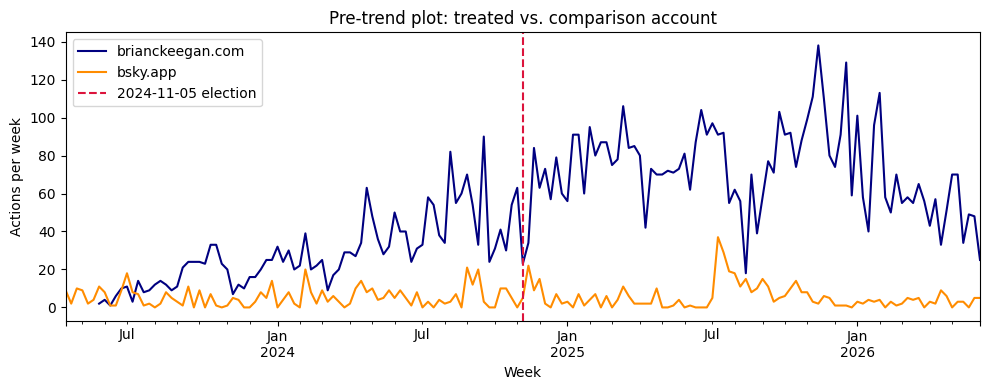

In [18]:
comparison_weekly = weekly_counts(comparison_posts, COMPARISON)

fig, ax = plt.subplots(figsize=(10, 4))
treated_weekly.plot(ax=ax, color='navy', lw=1.5, label=TREATED)
comparison_weekly.plot(ax=ax, color='darkorange', lw=1.5, label=COMPARISON)
ax.axvline(EVENT, color='crimson', ls='--', lw=1.5, label='2024-11-05 election')
ax.set_xlabel('Week')
ax.set_ylabel('Actions per week')
ax.set_title('Pre-trend plot: treated vs. comparison account')
ax.legend()
plt.tight_layout()

Squint at the pre-event period and form your own judgment — we will return to this plot critically in a moment. First, the mechanics. `make_did_panel` stacks the two weekly series into a **tidy panel**: one row per (account, week), with indicators for `treated`, `post`, and their interaction. We restrict to the weeks both accounts have in common so the panel is balanced.

In [19]:
common_weeks = treated_weekly.index.intersection(comparison_weekly.index)

panel = make_did_panel(
    {
        TREATED: treated_weekly.loc[common_weeks],
        COMPARISON: comparison_weekly.loc[common_weeks],
    },
    treated_actor=TREATED,
    event=EVENT,
)

panel.sample(5, random_state=5)

,week,actions,account,treated,post,treated_post
240,2024-12-15 00:00:00-07:00,0,bsky.app,0,1,0
227,2024-09-15 00:00:00-06:00,20,bsky.app,0,0,0
115,2025-08-10 00:00:00-06:00,56,brianckeegan.com,1,1,1
285,2025-10-26 00:00:00-06:00,8,bsky.app,0,1,0
99,2025-04-20 00:00:00-06:00,73,brianckeegan.com,1,1,1


The 2×2 table of group means *is* the difference-in-differences, computed by hand:

In [20]:
means = panel.groupby(['treated', 'post'])['actions'].mean().unstack()
means.index = [COMPARISON, TREATED]
means.columns = ['pre', 'post']

did_by_hand = (means.loc[TREATED, 'post'] - means.loc[TREATED, 'pre']) - (
    means.loc[COMPARISON, 'post'] - means.loc[COMPARISON, 'pre']
)

print(means.round(2))
print()
print('Difference-in-differences:', round(did_by_hand, 2), 'actions per week')

                    pre   post
bsky.app           5.37   5.52
brianckeegan.com  28.64  72.34

Difference-in-differences: 43.54 actions per week


The regression version, `actions = b0 + b1*treated + b2*post + b3*treated*post`, reproduces exactly that number as the interaction coefficient — and gives us standard errors:

In [21]:
did_results = fit_did(panel)

did_table = coefficient_table(
    did_results,
    names=['intercept', 'treated', 'post', 'treated_post'],
)
did_table.round(3)

,coef,std_err,t,p_value
term,,,,
intercept,5.368,1.788,3.002,0.003
treated,23.276,2.529,9.203,0.000
post,0.150,2.475,0.060,0.952
treated_post,43.543,3.500,12.439,0.000


**Interpretation:** `intercept` is the comparison account's pre-event weekly average; `treated` is how much more active the treated account already was before the event; `post` is the comparison account's before–after change (the "what happened to everyone" term); and `treated_post` — the DiD estimate — says the treated account gained roughly **40+ extra weekly actions** beyond the comparison account's change.

### Why this DiD should not be believed

Here is the part of the analysis that matters most, and that a dishonest write-up would omit. **`bsky.app` is a terrible comparison group**, for at least three reasons:

1. **It was also treated.** `bsky.app` is the platform's own account. During the November surge the Bluesky team was posting welcome threads, feature announcements, and status updates *because of the very event we are studying*. A comparison unit must be unaffected by the treatment; ours sits at the epicenter. Look back at the pre-trend plot: the orange series jumps at the event too, so the `post` coefficient absorbs some genuine event effect and our DiD estimate is biased (here, biased *downward*, since we subtract off a comparison change that is itself partly treatment effect).
2. **Parallel trends is visibly violated.** An organization's communications account and an individual academic's account do not share data-generating processes. Their pre-event levels differ by an order of magnitude, and their pre-event movements track product launches versus a person's life. Nothing about the orange line tells us what the navy line would have done absent the election.
3. **One unit per arm.** With a single treated and single comparison unit, we cannot separate "the effect of the event" from "anything idiosyncratic that happened to either account that month". Credible DiD designs use many units per arm, with uncertainty clustered at the unit level.

We chose this comparison deliberately: seeing the assumption fail on real data teaches more than a sanitized example where it silently holds. The estimate above is a worked *mechanical* example of DiD, not a defensible causal estimate.

## 7. Building a better comparison group: matching on profile covariates

What would a better comparison group look like? Accounts that resemble the treated account on observables — audience size, prior activity, account age — so that "parallel trends" is at least plausible. `get_profiles` ([`app.bsky.actor.getProfiles`](https://docs.bsky.app/docs/api/app-bsky-actor-get-profiles)) batches up to 25 profile lookups per request and returns exactly these covariates; `get_profile_covariates` in `timeseries.py` wraps the batching.

To get a candidate pool we grab one page of accounts the treated account follows via `get_follows` ([`app.bsky.graph.getFollows`](https://docs.bsky.app/docs/api/app-bsky-graph-get-follows)) (the kind of accounts that share its corner of the network — Part 03 built whole ego networks this way):

In [22]:
follows_page = client.get_follows(actor=TREATED, limit=50)
candidate_handles = [follow.handle for follow in follows_page.follows]

candidates = get_profile_covariates(client, candidate_handles)
candidates.head()

,followers,follows,posts,created_at,account_age_days
handle,,,,,
munsonalison.bsky.social,8156,5828,259,2023-07-28 01:18:47.438000+00:00,1048
laurachapin.bsky.social,7157,2655,7725,2023-10-29 22:11:32.745000+00:00,954
teagrjohnson.bsky.social,37,58,2,2024-10-02 03:20:44.408000+00:00,616
denicewross.bsky.social,109,34,6,2024-11-18 14:55:15.346000+00:00,568
csmarcum.bsky.social,761,52,112,2025-01-22 12:36:52.144000+00:00,503


A simple **nearest-neighbor match**: standardize the covariates (logging the heavy-tailed counts first, as in Part 04) and rank candidates by Euclidean distance to the treated account's profile.

In [23]:
treated_covariates = get_profile_covariates(client, [TREATED])

pool = pd.concat([candidates, treated_covariates]).dropna(
    subset=['followers', 'posts', 'account_age_days']
)
features = pd.DataFrame({
    'log_followers': np.log1p(pool['followers'].astype(float)),
    'log_posts': np.log1p(pool['posts'].astype(float)),
    'account_age_days': pool['account_age_days'].astype(float),
})
standardized = (features - features.mean()) / features.std()

distance = np.sqrt(
    ((standardized - standardized.loc[TREATED]) ** 2).sum(axis=1)
)

pool.assign(distance=distance).drop(index=TREATED).nsmallest(
    5, 'distance'
)[['followers', 'follows', 'posts', 'account_age_days', 'distance']]

,followers,follows,posts,account_age_days,distance
handle,,,,,
aschrock.bsky.social,4895,2557,1804,1072,0.253185
backlinenurse.bsky.social,3481,306,1020,1136,0.451734
audrajwolfe.bsky.social,2314,1112,1773,1072,0.462841
universalhub.com,12025,2283,5689,1118,0.476653
baym.lol,11023,1295,1339,1112,0.506155


These accounts are far more plausible comparisons than `bsky.app` — similar audience, similar activity, similar vintage. A real study would match on covariates measured *before* the event (note that `posts` and `followers` here are measured today, post-treatment — conditioning on post-treatment variables is itself a bias!), collect dozens of matched accounts per treated account, verify parallel pre-trends *empirically*, and only then estimate.

And we still should not overclaim. Matching makes accounts comparable on what we can **observe**; the November surge "treated" essentially everyone on Bluesky to some degree, so a fully untreated control may not exist *on this platform at all*. Designs that researchers used for exactly this problem on Twitter include comparison groups from a different platform, accounts in unaffected countries or timezones, or dose-response designs (accounts more vs. less exposed to the migration wave). The hard part of causal inference is never the regression — it is the argument for the counterfactual.

## 8. Keyword volume around an event (requires authentication)

Account histories are one lens on an event; **keyword volume** is another. `search_posts` ([`app.bsky.feed.searchPosts`](https://docs.bsky.app/docs/api/app-bsky-feed-search-posts)) accepts `since` and `until` parameters, so you can build a topic's time series by issuing one search per time window and counting (or capping) the results — exactly how researchers built event timelines from Twitter's search API (González-Bailón et al. 2011 tracked protest hashtags this way).

The search endpoint returns `403` without authentication, so — as in Part 02 — the working code runs only if you have `atproto.json` credentials. Two cautions for when you do run it: search queries an **index**, not the full network history — deletions and opt-outs create survivorship bias — and capping each window at 1,000 results turns high-volume weeks into a censored measure, so for popular keywords treat the series as a floor, not a count.

In [24]:
if is_authenticated(client):

    def keyword_weekly_volume(client, query, start, end, max_per_window=1000):
        """Count posts matching ``query`` in each weekly window via searchPosts."""
        edges = pd.date_range(start, end, freq='W', tz='UTC')
        counts = {}
        for window_start, window_end in zip(edges[:-1], edges[1:]):
            total, cursor = 0, None
            while True:
                response = client.app.bsky.feed.search_posts(
                    params={
                        'q': query,
                        'since': window_start.strftime('%Y-%m-%dT%H:%M:%SZ'),
                        'until': window_end.strftime('%Y-%m-%dT%H:%M:%SZ'),
                        'limit': 100,
                        'cursor': cursor,
                    }
                )
                total += len(response.posts)
                cursor = response.cursor
                if cursor is None or total >= max_per_window:
                    break
                time.sleep(0.1)
            counts[window_end] = total
            time.sleep(0.1)
        return pd.Series(counts, name=query)

    volume = keyword_weekly_volume(client, 'twitter', '2024-10-01', '2024-12-31')

    fig, ax = plt.subplots(figsize=(10, 4))
    volume.plot(ax=ax, color='navy', lw=1.5)
    ax.axvline(pd.Timestamp('2024-11-05', tz='UTC'), color='crimson', ls='--', lw=1.5)
    ax.set_ylabel('Posts per week (capped at 1,000)')
    ax.set_title("Weekly volume of posts matching 'twitter'")
    plt.tight_layout()

else:
    print('searchPosts requires authentication and this client is unauthenticated.')
    print('Save your credentials in atproto.json (see Part 00) and re-run this cell')
    print('to build a weekly keyword-volume series around the event.')

searchPosts requires authentication and this client is unauthenticated.
Save your credentials in atproto.json (see Part 00) and re-run this cell
to build a weekly keyword-volume series around the event.


## 9. Saving and reloading the data

Collection took nearly a hundred API requests; analysis should not require repeating it. As in Part 01, we persist the derived data to `data/` so the modeling cells can be re-run offline — and we record *when* and *how* the data were collected, because live feeds change (posts get deleted, accounts get renamed) and a result that cannot be tied to a collection date cannot be checked.

We save:

* `data/daily_counts.csv` — daily action counts for both accounts (the weekly series and everything downstream can be rebuilt from this),
* `data/its_results.csv` — the tidy ITS coefficient table,
* `data/collection_metadata.json` — collection date, accounts, parameters, and the event date.

In [25]:
daily_both = pd.concat(
    {
        TREATED: treated_daily,
        COMPARISON: daily_counts(comparison_posts, COMPARISON),
    },
    axis=1,
    sort=True,
).fillna(0).astype(int)
daily_both.index.name = 'date'

daily_both.to_csv('data/daily_counts.csv')
its_table.to_csv('data/its_results.csv')

metadata = {
    'collected_at': pd.Timestamp.now(tz='UTC').isoformat(),
    'accounts': {
        'treated': TREATED,
        'comparison': COMPARISON,
    },
    'n_actions': {
        TREATED: len(treated_posts),
        COMPARISON: len(comparison_posts),
    },
    'event': '2024-11-05',
    'timezone': 'America/Denver',
    'endpoint': 'app.bsky.feed.getAuthorFeed',
    'page_size': 100,
}
with open('data/collection_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

daily_both.tail()

,brianckeegan.com,bsky.app
date,,
2026-06-05 00:00:00-06:00,8,1
2026-06-06 00:00:00-06:00,3,0
2026-06-07 00:00:00-06:00,5,0
2026-06-08 00:00:00-06:00,0,1
2026-06-09 00:00:00-06:00,9,0


Reloading demonstrates the round trip — and one last timezone lesson. The CSV stores timestamps as ISO strings with their UTC offsets (`-06:00` or `-07:00` depending on daylight saving). The robust way back is to parse **to UTC first**, then convert to the local zone:

In [26]:
reloaded = pd.read_csv('data/daily_counts.csv')
reloaded['date'] = pd.to_datetime(
    reloaded['date'], utc=True, format='ISO8601'
).dt.tz_convert('America/Denver')
reloaded = reloaded.set_index('date')

print('Round trip matches:', reloaded.equals(daily_both))
reloaded.tail()

Round trip matches: True


,brianckeegan.com,bsky.app
date,,
2026-06-05 00:00:00-06:00,8,1
2026-06-06 00:00:00-06:00,3,0
2026-06-07 00:00:00-06:00,5,0
2026-06-08 00:00:00-06:00,0,1
2026-06-09 00:00:00-06:00,9,0


## 10. Research design: what it takes to claim causation

Step back from the mechanics. Both designs in this notebook are **quasi-experimental**: nobody randomized accounts into "experience the November surge" and "don't". Instead we leaned on a *natural experiment* — an event with sharp, externally-determined timing — and on design assumptions that substitute for randomization. Those assumptions are where causal claims live or die. The recurring **threats to validity**:

* **Selection.** Who is in the treated group, and why? Our treated account is on Bluesky (and in this dataset) precisely because its owner is the kind of person who joined early and posts about platform migrations. Effects estimated on self-selected units do not generalize to people who chose differently.
* **Anticipation.** Treatments with announced timing leak backward. Users disaffected with X were drifting to Bluesky throughout 2024; if behavior shifts *before* the event date, the "pre" period is contaminated and the estimated jump is too small or too large. (Inspect the weeks just before the event line in Section 4.)
* **Concurrent shocks.** The election was not only a migration trigger — it was a massive news event that changed everyone's posting, everywhere. ITS cannot separate co-timed causes at all; DiD can only if the comparison group absorbs the shared shock, which requires the comparison to be exposed to the news but not the migration.
* **Parallel trends / counterfactual credibility.** ITS assumes the pre-trend would have continued; DiD assumes the comparison's change reveals the treated counterfactual. Section 6 showed how visibly this can fail. Pre-trend plots, placebo events (rerun the ITS on a date when nothing happened — a significant "effect" there is a red flag), and multiple comparison units are the standard diagnostics.

This is why **correlation-only claims fail**: "posting rose after the election" is consistent with the event causing the rise, with a pre-existing trend, with seasonality, with a concurrent shock, and with regression to the mean after a lull. A design's job is to rule those out one by one — and a write-up's job is to say plainly which ones it could not rule out.

## Ethics and limitations

**Ethics.** Posting histories are public, but assembling someone's complete three-year behavioral trace — when they sleep, when they work, when they go quiet — is more intrusive than reading any individual post, and timestamp analysis can reveal patterns (timezone, schedule, life disruptions) that users never chose to disclose. This notebook studies the author's own account by his choice and an official organizational account; apply the same designs to private individuals only with a research justification, minimal fields, and aggregate reporting (we kept only URIs, timestamps, action types, and counts — no text). The matching section retrieves other accounts' public profile statistics; report such covariates in aggregate rather than ranking named individuals. And remember deletion: users remove posts, so a saved archive is a snapshot — record the collection date (we did) and honor deletions when sharing data.

**Limitations.** Everything here measures *visible platform behavior*, not underlying attention or attitudes — absence of posting is not absence of activity (lurking is invisible). Two accounts cannot support population claims; Bluesky's user base over-represents Twitter migrants and early adopters, and November 2024 in particular reshaped who is on the platform at all (a selection effect *caused by* our event of study). Author feeds exclude deleted posts, so the past is measured with survivorship bias. Weekly counts treat a one-word repost and a 20-post thread identically. And our event study has a single treated unit and a knowingly invalid comparison — it is a teaching design; a publishable version needs many matched accounts, pre-registered event windows, placebo tests, and honesty about the threats listed in Section 10.

## Exercises

These extend the notebook, ordered from small modifications to mini-analyses. All of them can be done with the data and helpers already loaded above.

1. **Change the timezone.** Re-run `history_to_frame` on `treated_records` with a different timezone (e.g., `tz='Europe/London'` or `tz='Asia/Tokyo'` — any [IANA zone name](https://en.wikipedia.org/wiki/List_of_tz_database_time_zones) works) and redraw the Section 3 diurnal profile. The sleep trough should move to wherever your chosen zone places a Colorado resident's night.

2. **Original posts only.** Section 2 showed that reposts outnumber original posts. Rebuild `treated_weekly` from `treated_posts.query("action == 'post'")` and re-fit the ITS. Do the level shift and trend change survive this robustness check, or was the November surge mostly a *reposting* surge?

3. **Placebo event.** Re-run `fit_its(treated_weekly, ...)` with a fake event date on which nothing notable happened — say `pd.Timestamp('2024-05-01', tz='America/Denver')`. A "significant" level shift at a date you invented is a red flag that the design, not the event, is generating findings. Report the placebo coefficients side by side with the real ones.

4. **Stress-test the standard errors.** Recompute the HAC table from Section 5 with `maxlags` of 1, 8, and 12 instead of 4. How sensitive are the conclusions about `level_shift` and `trend_change` to this choice? There is no single correct lag length — reporting the sensitivity is the honest move.

5. **A better comparison account, a better DiD.** Pick the nearest matched account from Section 7 (or any account you can argue is a better comparison than `bsky.app`), collect its history with `fetch_history`, and redo the pre-trend plot and DiD from Section 6. Is parallel trends more plausible? Does the DiD estimate move, and in which direction?

6. **A different event.** Bluesky dropped its invite-code requirement and opened public registration on **February 6, 2024**. Re-run the ITS around that date. Is there a detectable break, and how does its shape (level shift vs. slope change) compare with the November surge?

## Research project ideas

Sketches a student could develop into a term paper or thesis chapter with this part's methods.

**1. Dose–response in the X-odus.** *Question:* did existing Bluesky users who were more exposed to the November 2024 migration wave change their own posting more? *Data:* a sample of accounts created well before October 2024 (so that being in the sample is not itself caused by the event), each account's posting history via `getAuthorFeed`, and an exposure ("dose") measure such as the share of each account's pre-event follows who were publicly active in migration conversations (Part 03's network tools help here). *Method:* a continuous-treatment event study — interact the post-event indicator with dose, or fit separate ITS models by dose tercile — with HAC or account-clustered standard errors. *Expected challenge:* naive dose measures (e.g., follower growth during the surge) are themselves outcomes of the event, so the design hinges on finding a pre-determined exposure proxy and arguing candidly about the endogeneity that remains.

**2. Feature launches as interrupted time series.** *Question:* do platform feature launches — in-app video, DMs, cashtags, whichever launch is recent when you read this — change how much and what people post? *Data:* weekly post volumes and post-type shares (links, images, video, replies) for a panel of a few hundred accounts sampled *before* the launch, collected with this part's pagination helpers or platform-wide via Part 10's Jetstream tools. *Method:* ITS on the aggregate share of posts using the new feature, with placebo dates before the launch; if the rollout was staggered across user groups, the staggering supports a DiD between early- and late-access accounts. *Expected challenge:* launches are announced in advance and rolled out gradually, so the "interruption" is fuzzy — reconstruct the exact timeline from the [Bluesky blog](https://bsky.social/about/blog) and show your results are robust to the choice of event date.

**3. News shocks and topical attention with keyword series.** *Question:* how fast does attention to a sudden news event rise and decay on Bluesky, and does it crowd out other topics? *Data:* weekly or daily keyword-volume series built with the authenticated `searchPosts` loop from Section 8, for both event-related keywords and a basket of placebo keywords unrelated to the event. *Method:* ITS on the event keywords with the placebo basket as comparison series — a difference-in-differences in attention — looking for the explosive-onset, slow-decay dynamics González-Bailón et al. (2011) documented for protest hashtags. *Expected challenge:* the search index undercounts (deletions, opt-outs) and the per-window cap censors high-volume weeks, so the series is a floor rather than a count; validate a few windows against an independent measure such as Jetstream sampling.

## References

### Scholarship

* Golder, S. A., & Macy, M. W. (2011). Diurnal and seasonal mood vary with work, sleep, and daylength across diverse cultures. *Science*, 333(6051), 1878–1881. [https://doi.org/10.1126/science.1202775](https://doi.org/10.1126/science.1202775)
* Dodds, P. S., Harris, K. D., Kloumann, I. M., Bliss, C. A., & Danforth, C. M. (2011). Temporal patterns of happiness and information in a global social network: Hedonometrics and Twitter. *PLOS ONE*, 6(12), e26752. [https://doi.org/10.1371/journal.pone.0026752](https://doi.org/10.1371/journal.pone.0026752)
* González-Bailón, S., Borge-Holthoefer, J., Rivero, A., & Moreno, Y. (2011). The dynamics of protest recruitment through an online network. *Scientific Reports*, 1, 197. [https://doi.org/10.1038/srep00197](https://doi.org/10.1038/srep00197)

* Bernal, J. L., Cummins, S., & Gasparrini, A. (2017). Interrupted time series regression for the evaluation of public health interventions: a tutorial. *International Journal of Epidemiology*, 46(1), 348–355. [https://doi.org/10.1093/ije/dyw098](https://doi.org/10.1093/ije/dyw098)
* Card, D., & Krueger, A. B. (1994). Minimum wages and employment: A case study of the fast-food industry in New Jersey and Pennsylvania. *American Economic Review*, 84(4), 772–793. (The classic difference-in-differences study.)
* Cunningham, S. (2021). *Causal Inference: The Mixtape*. Yale University Press. Free online at [https://mixtape.scunning.com/](https://mixtape.scunning.com/)
* Huntington-Klein, N. (2021). *The Effect: An Introduction to Research Design and Causality*. CRC Press. Free online at [https://theeffectbook.net/](https://theeffectbook.net/)
* Angrist, J. D., & Pischke, J.-S. (2009). *Mostly Harmless Econometrics: An Empiricist's Companion*. Princeton University Press.

### Documentation

* Bluesky API endpoints used in this part: [`getAuthorFeed`](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed), [`getProfiles`](https://docs.bsky.app/docs/api/app-bsky-actor-get-profiles), [`getFollows`](https://docs.bsky.app/docs/api/app-bsky-graph-get-follows), [`searchPosts`](https://docs.bsky.app/docs/api/app-bsky-feed-search-posts)
* pandas: [time series user guide](https://pandas.pydata.org/docs/user_guide/timeseries.html) (resampling, time-zone handling), [`resample`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html), [`tz_convert`](https://pandas.pydata.org/docs/reference/api/pandas.Series.tz_convert.html), [`rolling`](https://pandas.pydata.org/docs/reference/api/pandas.Series.rolling.html)
* statsmodels: [linear regression and OLS](https://www.statsmodels.org/stable/regression.html), [HAC (Newey–West) robust covariance](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.get_robustcov_results.html)